In [2]:
import os
import pandas as pd

In [8]:
import pandas as pd
from io import StringIO

# 读取文件
with open(r'healthy\Signal\sigSp4-H18.txt', 'r', encoding='utf-8') as f:
    lines = f.readlines()

# 跳过所有以 # 开头的行
data_lines = [line for line in lines if not line.strip().startswith('#')]

# 将所有数据行合并为一个字符串
data_text = ''.join(data_lines)

# 使用 pandas 读取为 DataFrame
df = pd.read_csv(StringIO(data_text), delim_whitespace=True, header=None)

# 设置列名
df.columns = [
    "Microphone",
    "Fingergrip",
    "Axial_Pressure",
    "X_Acceleration",
    "Y_Acceleration",
    "Z_Acceleration"
]

df

,Microphone,Fingergrip,Axial_Pressure,X_Acceleration,Y_Acceleration,Z_Acceleration
0,3.362339,5.947486,8.922360,6.11217,5.47544,4.83541
1,2.833746,5.942803,8.897873,6.11217,5.47544,4.83541
2,2.893273,5.933687,8.846126,6.11217,5.47544,4.83541
3,3.006411,5.918860,8.768125,6.11217,5.35887,4.93658
4,3.114616,5.899613,8.664301,5.96151,5.23460,5.02786
...,...,...,...,...,...,...
4595,3.012425,5.878029,5.979744,5.09494,4.82001,5.96151
4596,3.005206,5.874494,5.978695,5.09494,4.82001,5.96151
4597,3.003103,5.874138,5.977619,5.09494,4.82001,5.96151
4598,3.002331,5.871441,5.975990,5.09494,4.82001,5.96151


### 批量处理

In [9]:
def save2csv(file_path, csv_folder):
    # 读取文件
    with open(file_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()

    # 跳过所有以 # 开头的行
    data_lines = [line for line in lines if not line.strip().startswith('#')]

    # 将所有数据行合并为一个字符串
    data_text = ''.join(data_lines)

    # 使用 pandas 读取为 DataFrame
    df = pd.read_csv(StringIO(data_text), delim_whitespace=True, header=None)

    # 设置列名
    df.columns = [
        "Microphone",
        "Fingergrip",
        "Axial_Pressure",
        "X_Acceleration",
        "Y_Acceleration",
        "Z_Acceleration"
    ]

    df.to_csv(os.path.join(csv_folder, os.path.basename(file_path)[:-3] + 'csv'),
              index=False, encoding='utf-8')

In [10]:
root = r'healthy\Signal'
for file in os.listdir(root):
    save2csv(os.path.join(root, file),
             csv_folder=r'healthy\HealthySignal')

In [11]:
root = r'patient\Signal'
for file in os.listdir(root):
    save2csv(os.path.join(root, file),
             csv_folder=r'patient\PatientSignal')

### 构造数据集

In [19]:
# Circle
h_images = [f[:-4] for f in os.listdir(r'healthy\Circle')]
h_signals = [f[:-4] for f in os.listdir(r'healthy\HealthySignal')]

h_both = [f for f in h_images if f[:6] + 'H' + f[7:] in h_signals]

len(h_images), len(h_signals), len(h_both)

(35, 420, 35)

In [22]:
p_images = [f[:-4] for f in os.listdir(r'patient\Circle')]
p_signals = [f[:-4] for f in os.listdir(r'patient\PatientSignal')]

p_both = [f for f in p_images if f in p_signals]

len(p_images), len(p_signals), len(p_both)

(31, 372, 31)

In [26]:
images = ['healthy/Circle/' + f + '.jpg' for f in h_images] \
       + ['patient/Circle/' + f + '.jpg' for f in p_images]

signals = ['healthy/HealthySignal/' + f[:6] + 'H' + f[7:] + '.csv' for f in h_both] \
        + ['patient/PatientSignal/' + f + '.csv' for f in p_both]

labels = [0] * len(h_images) + [1] * len(p_images)

len(images), len(signals), len(labels)

(66, 66, 66)

In [27]:
data = {
    'images': images,
    'signals': signals,
    'labels': labels
}
pd.DataFrame(data).to_csv('circle.csv', index=False, header=None, encoding='utf-8')

In [4]:
# Meander
h_images = [f[:-4] for f in os.listdir(r'healthy\HealthyMeander')]
h_signals = [f[:-4] for f in os.listdir(r'healthy\HealthySignal')]

h_both = [f for f in h_images if 'sigM' + f[1:] in h_signals]

len(h_images), len(h_signals), len(h_both)

(140, 420, 139)

In [6]:
p_images = [f[:-4] for f in os.listdir(r'patient\PatientMeander')]
p_signals = [f[:-4] for f in os.listdir(r'patient\PatientSignal')]

p_both = [f for f in p_images if 'sigM' + f[1:] in p_signals]

len(p_images), len(p_signals), len(p_both)

(124, 372, 123)

In [8]:
images = ['healthy/HealthyMeander/' + f + '.jpg' for f in h_both] \
       + ['patient/PatientMeander/' + f + '.jpg' for f in p_both]

signals = ['healthy/HealthySignal/' + 'sigM' + f[1:] + '.csv' for f in h_both] \
        + ['patient/PatientSignal/' + 'sigM' + f[1:] + '.csv' for f in p_both]

labels = [0] * len(h_both) + [1] * len(p_both)

len(images), len(signals), len(labels)

(262, 262, 262)

In [9]:
data = {
    'images': images,
    'signals': signals,
    'labels': labels
}
pd.DataFrame(data).to_csv('meander.csv', index=False, header=None, encoding='utf-8')

In [10]:
# Spiral
h_images = [f[:-4] for f in os.listdir(r'healthy\HealthySpiral')]
h_signals = [f[:-4] for f in os.listdir(r'healthy\HealthySignal')]

h_both = [f for f in h_images if 'sigS' + f[1:] in h_signals]

len(h_images), len(h_signals), len(h_both)

(140, 420, 140)

In [11]:
p_images = [f[:-4] for f in os.listdir(r'patient\PatientSpiral')]
p_signals = [f[:-4] for f in os.listdir(r'patient\PatientSignal')]

p_both = [f for f in p_images if 'sigS' + f[1:] in p_signals]

len(p_images), len(p_signals), len(p_both)

(124, 372, 124)

In [12]:
images = ['healthy/HealthySpiral/' + f + '.jpg' for f in h_both] \
       + ['patient/PatientSpiral/' + f + '.jpg' for f in p_both]

signals = ['healthy/HealthySignal/' + 'sigS' + f[1:] + '.csv' for f in h_both] \
        + ['patient/PatientSignal/' + 'sigS' + f[1:] + '.csv' for f in p_both]

labels = [0] * len(h_both) + [1] * len(p_both)

len(images), len(signals), len(labels)

(264, 264, 264)

In [13]:
data = {
    'images': images,
    'signals': signals,
    'labels': labels
}
pd.DataFrame(data).to_csv('spiral.csv', index=False, header=None, encoding='utf-8')

In [ ]:
import os
import pandas as pd
import numpy as np
import torch
from torch.nn import functional as F
import torchvision
from torch.utils.data import Dataset, DataLoader
from PIL import Image

class ImageSignalDataset(Dataset):
    """
    """
    def __init__(self, images_path, signals_path, labels):
        super().__init__()
        self.images_path = images_path
        self.signals_path = signals_path
        self.labels = labels

        # 图片归一化
        self.image_norm = torchvision.transforms.Compose([
            torchvision.transforms.Resize((244, 244)),
            torchvision.transforms.ToTensor(),
            torchvision.transforms.Normalize([0.4914, 0.4822, 0.4465],
                                             [0.2023, 0.1994, 0.2010])
        ])
    
    def signal_norm(self, signal):
        """ 信号序列处理 signal shape: (L, C) """
        signal = torch.as_tensor(signal.T).unsqueeze(0)    # (1, C, L)
        
        # 在L维度插值/采样为10000
        signal = F.interpolate(signal, size=10000, mode='linear', align_corners=True)

        return signal.squeeze(0)    # shape: (C, 10000)
    
 
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, index):
        image = Image.open(self.images_path[index]).convert('RGB')
        image = self.image_norm(image)

        signal = pd.read_csv(self.signals_path[index]).values
        signal = self.signal_norm(signal)

        return image, signal, self.labels[index]

In [22]:
from sklearn.model_selection import train_test_split

def get_dataloader(index_file, batch_size, drop_last=False):
    """ 获取train_iter test_iter """
    images_path, signals_path, labels = pd.read_csv(index_file, header=None).values.T
    
    # 划分训练集/测试集
    train_img, test_img, train_sig, test_sig, train_lbl, test_lbl = train_test_split(
        images_path, signals_path, labels,
        test_size=0.2, random_state=29, shuffle=True
    )

    train_iter = DataLoader(
        ImageSignalDataset(train_img, train_sig, train_lbl),
        batch_size=batch_size, shuffle=True, drop_last=drop_last
    )
    test_iter = DataLoader(
        ImageSignalDataset(test_img, test_sig, test_lbl),
        batch_size=batch_size, shuffle=False, drop_last=drop_last
    )

    return train_iter, test_iter

In [32]:
train_iter, test_iter = get_dataloader('circle.csv', batch_size=4)

a, b, c = next(iter(train_iter))
a.shape, b.shape, c.shape

(torch.Size([4, 3, 244, 244]), torch.Size([4, 6, 10000]), torch.Size([4]))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


array([<Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object)

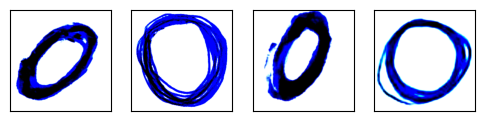

In [35]:
from d2l import torch as d2l

d2l.show_images(a.permute(0, 2, 3, 1), 1, 4)